# Automated Ubuntu System Health Monitoring and Alert Dashboard

**Coursework Automation Scenario**  
**Environment:** Google Colab / Ubuntu-based Linux environment

## Idea

This notebook demonstrates one automation scenario: a simulated Ubuntu system health monitor. In a real Ubuntu server, administrators often automate scripts to watch CPU, memory, disk, and network activity. This project simulates that process using generated data, automatic alert rules, log files, and visual dashboards.

## Automation Goal

Automatically monitor server health, detect risky resource usage, create alert logs, and visualize the results for quick decision-making.

## Scenario Explanation

The automation performs these tasks:

1. Simulates Ubuntu server metrics for one full day.
2. Applies alert rules for CPU, RAM, disk, and network usage.
3. Saves monitoring data as a CSV file.
4. Saves alert messages as a Linux-style log file.
5. Produces graphs to help understand system behavior.

This is relevant to Ubuntu automation because similar workflows can be scheduled with `cron`, implemented with shell/Python scripts, and used in real server administration.

In [1]:
# Install dependencies if needed in Google Colab
# Colab already includes most of these libraries, but this keeps the notebook portable.
!pip -q install pandas numpy matplotlib seaborn

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

np.random.seed(42)
print("Notebook is ready. Output folder:", OUTPUT_DIR.resolve())

Notebook is ready. Output folder: /Users/mirsaid/workspaces/services/projects/univ-op/ai-usage-analysis/4-Ubuntu-System-Health-Automation/outputs


## Step 1: Simulate Ubuntu Monitoring Data

In a real Ubuntu environment, this data could be collected with commands such as `top`, `free -m`, `df -h`, `ifstat`, or Python libraries such as `psutil`. For this assignment, simulated data is used so the notebook works consistently in Google Colab.

In [3]:
timestamps = pd.date_range("2026-05-29 00:00", periods=144, freq="10min")
n = len(timestamps)

# Normal daily patterns plus random variation
hour = (timestamps.hour + timestamps.minute / 60).to_numpy()
workload_wave = 18 * np.sin((hour - 8) / 24 * 2 * np.pi) + 18

cpu_percent = np.clip(25 + workload_wave + np.random.normal(0, 8, n), 5, 100)
ram_percent = np.clip(40 + workload_wave * 0.7 + np.random.normal(0, 6, n), 10, 100)
disk_percent = np.clip(55 + np.linspace(0, 14, n) + np.random.normal(0, 1.5, n), 50, 95)
network_mbps = np.clip(30 + workload_wave * 1.5 + np.random.normal(0, 18, n), 1, 200)

# Inject a few realistic abnormal periods
cpu_percent[55:64] = np.clip(cpu_percent[55:64] + 35, 0, 100)
ram_percent[78:88] = np.clip(ram_percent[78:88] + 30, 0, 100)
disk_percent[116:124] = np.clip(disk_percent[116:124] + 18, 0, 100)
network_mbps[35:42] = np.clip(network_mbps[35:42] + 95, 0, 250)

df = pd.DataFrame({
    "timestamp": timestamps,
    "cpu_percent": cpu_percent.round(2),
    "ram_percent": ram_percent.round(2),
    "disk_percent": disk_percent.round(2),
    "network_mbps": network_mbps.round(2),
})

df.head()

,timestamp,cpu_percent,ram_percent,disk_percent,network_mbps
0,2026-05-29 00:00:00,31.39,43.25,55.42,28.77
1,2026-05-29 00:10:00,25.93,46.11,54.16,45.97
2,2026-05-29 00:20:00,31.87,33.76,54.88,59.57
3,2026-05-29 00:30:00,38.55,33.04,54.55,33.39
4,2026-05-29 00:40:00,24.21,43.89,54.51,60.94


## Step 2: Automation Rules

The automated monitor uses threshold rules. When a metric crosses a threshold, the script creates an alert. These rules imitate how Ubuntu monitoring scripts or scheduled cron jobs can automatically warn an administrator.

In [4]:
THRESHOLDS = {
    "cpu_percent": 85,
    "ram_percent": 85,
    "disk_percent": 90,
    "network_mbps": 145,
}

def classify_status(row):
    alerts = []
    if row["cpu_percent"] >= THRESHOLDS["cpu_percent"]:
        alerts.append("CPU overload")
    if row["ram_percent"] >= THRESHOLDS["ram_percent"]:
        alerts.append("RAM pressure")
    if row["disk_percent"] >= THRESHOLDS["disk_percent"]:
        alerts.append("Disk almost full")
    if row["network_mbps"] >= THRESHOLDS["network_mbps"]:
        alerts.append("Network spike")
    return "OK" if not alerts else "; ".join(alerts)

df["status"] = df.apply(classify_status, axis=1)
df["has_alert"] = df["status"] != "OK"

df[df["has_alert"]].head(10)

,timestamp,cpu_percent,ram_percent,disk_percent,network_mbps,status,has_alert
35,2026-05-29 05:50:00,23.56,62.15,61.57,151.13,Network spike,True
41,2026-05-29 06:50:00,38.96,53.10,59.96,168.48,Network spike,True
55,2026-05-29 09:10:00,90.86,49.53,59.62,45.65,CPU overload,True
58,2026-05-29 09:40:00,88.26,64.42,58.51,68.27,CPU overload,True
59,2026-05-29 09:50:00,94.12,64.74,58.67,96.11,CPU overload,True
61,2026-05-29 10:10:00,86.19,53.74,60.65,56.00,CPU overload,True
78,2026-05-29 13:00:00,61.12,98.89,62.97,87.95,RAM pressure,True
79,2026-05-29 13:10:00,44.67,85.23,62.75,82.46,RAM pressure,True
80,2026-05-29 13:20:00,58.97,92.18,62.98,79.29,RAM pressure,True
81,2026-05-29 13:30:00,63.70,100.00,61.77,67.43,RAM pressure,True


## Step 3: Save Automated Outputs

The automation saves a monitoring CSV and a text log. This is similar to how Linux automation tasks commonly store records in files for later auditing.

In [5]:
csv_path = OUTPUT_DIR / "system_health_metrics.csv"
log_path = OUTPUT_DIR / "system_alerts.log"

df.to_csv(csv_path, index=False)

alert_rows = df[df["has_alert"]]
with open(log_path, "w", encoding="utf-8") as log_file:
    for _, row in alert_rows.iterrows():
        log_file.write(
            f"{row['timestamp']} ubuntu-monitor ALERT {row['status']} "
            f"cpu={row['cpu_percent']} ram={row['ram_percent']} "
            f"disk={row['disk_percent']} network={row['network_mbps']}Mbps\n"
        )

print("Saved:", csv_path)
print("Saved:", log_path)
print("Total readings:", len(df))
print("Total alerts:", len(alert_rows))

Saved: outputs/system_health_metrics.csv
Saved: outputs/system_alerts.log
Total readings: 144
Total alerts: 16


## Step 4: Alert Summary Analysis

This analysis shows how many alert types occurred. It helps identify the main system risk during the simulated day.

In [6]:
alert_counts = {
    "CPU overload": df["status"].str.contains("CPU overload").sum(),
    "RAM pressure": df["status"].str.contains("RAM pressure").sum(),
    "Disk almost full": df["status"].str.contains("Disk almost full").sum(),
    "Network spike": df["status"].str.contains("Network spike").sum(),
}

alert_summary = pd.DataFrame({
    "alert_type": list(alert_counts.keys()),
    "count": list(alert_counts.values()),
}).sort_values("count", ascending=False)

alert_summary

,alert_type,count
1,RAM pressure,10
0,CPU overload,4
3,Network spike,2
2,Disk almost full,0


## Step 5: Visual Dashboard

The charts below visualize the automated monitoring results. Red dashed lines represent alert thresholds.

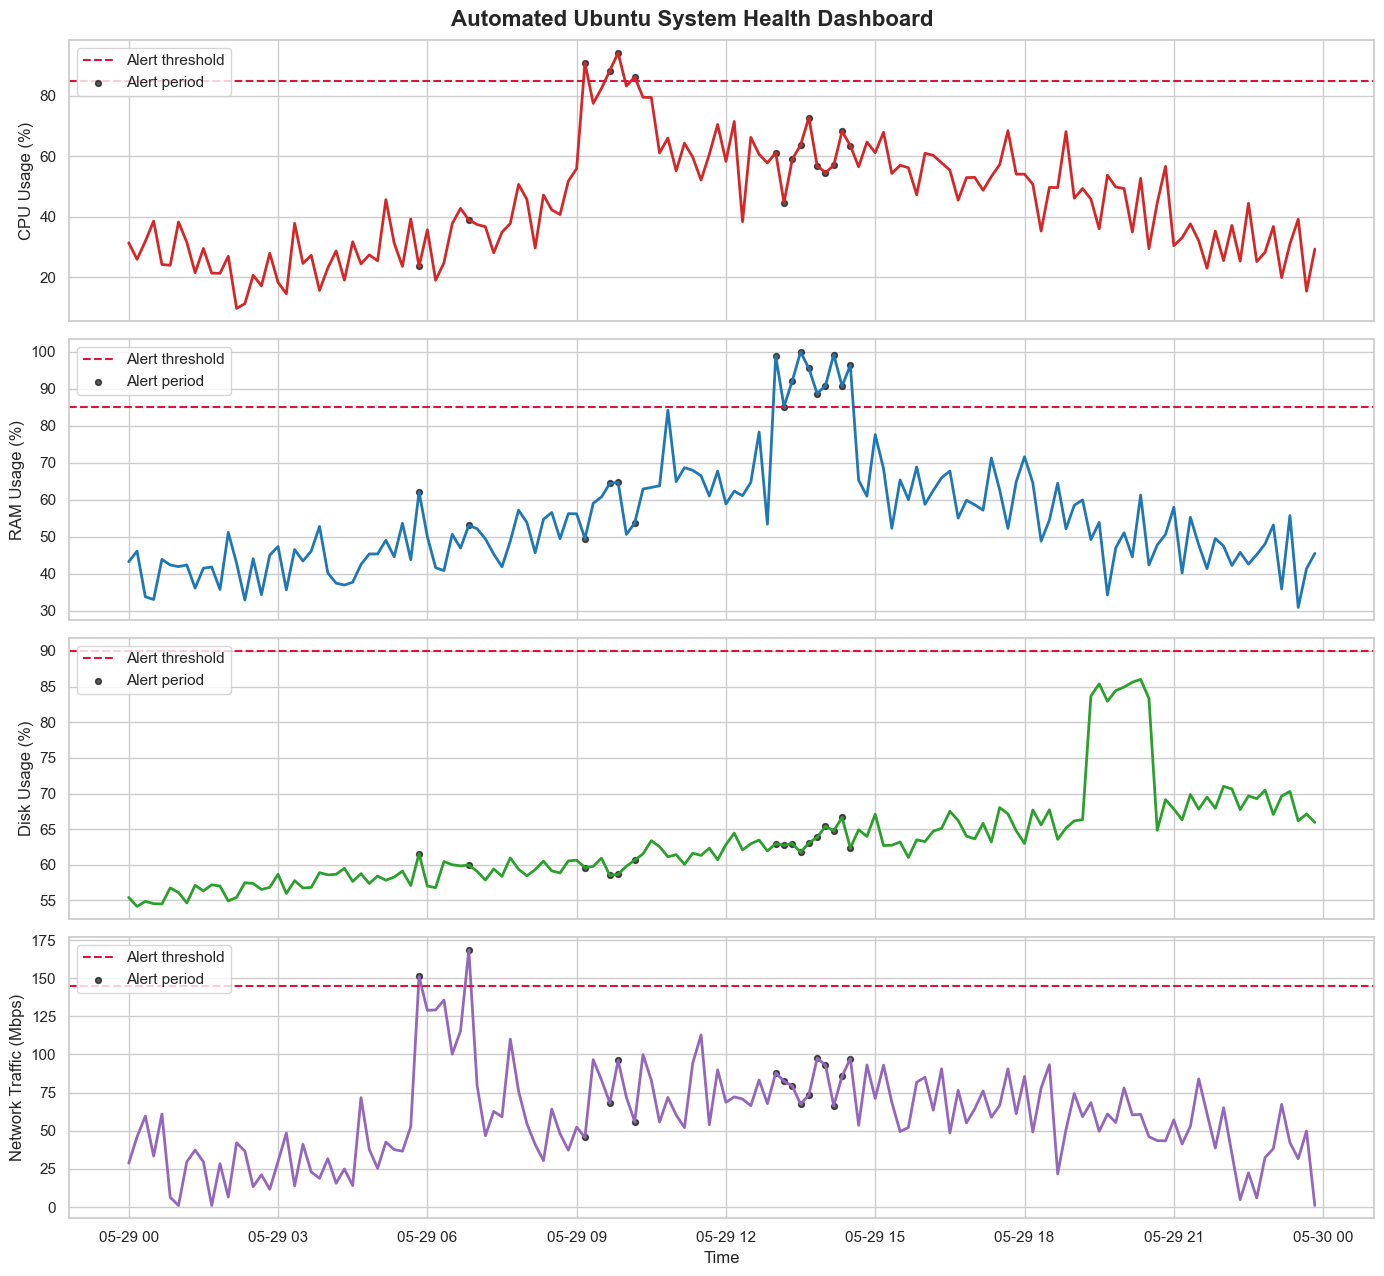

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

metrics = [
    ("cpu_percent", "CPU Usage (%)", THRESHOLDS["cpu_percent"], "tab:red"),
    ("ram_percent", "RAM Usage (%)", THRESHOLDS["ram_percent"], "tab:blue"),
    ("disk_percent", "Disk Usage (%)", THRESHOLDS["disk_percent"], "tab:green"),
    ("network_mbps", "Network Traffic (Mbps)", THRESHOLDS["network_mbps"], "tab:purple"),
]

for ax, (column, label, threshold, color) in zip(axes, metrics):
    ax.plot(df["timestamp"], df[column], color=color, linewidth=2)
    ax.axhline(threshold, color="crimson", linestyle="--", linewidth=1.5, label="Alert threshold")
    ax.scatter(
        df.loc[df["has_alert"], "timestamp"],
        df.loc[df["has_alert"], column],
        color="black",
        s=18,
        alpha=0.65,
        label="Alert period"
    )
    ax.set_ylabel(label)
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Time")
fig.suptitle("Automated Ubuntu System Health Dashboard", fontsize=16, weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "system_health_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

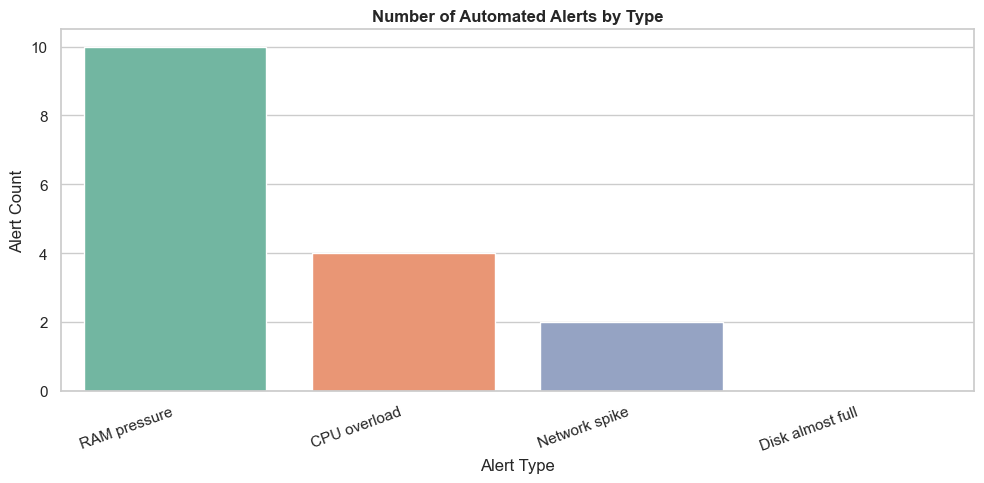

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=alert_summary, x="alert_type", y="count", hue="alert_type", palette="Set2", legend=False)
plt.title("Number of Automated Alerts by Type", weight="bold")
plt.xlabel("Alert Type")
plt.ylabel("Alert Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "alert_type_summary.png", dpi=150, bbox_inches="tight")
plt.show()

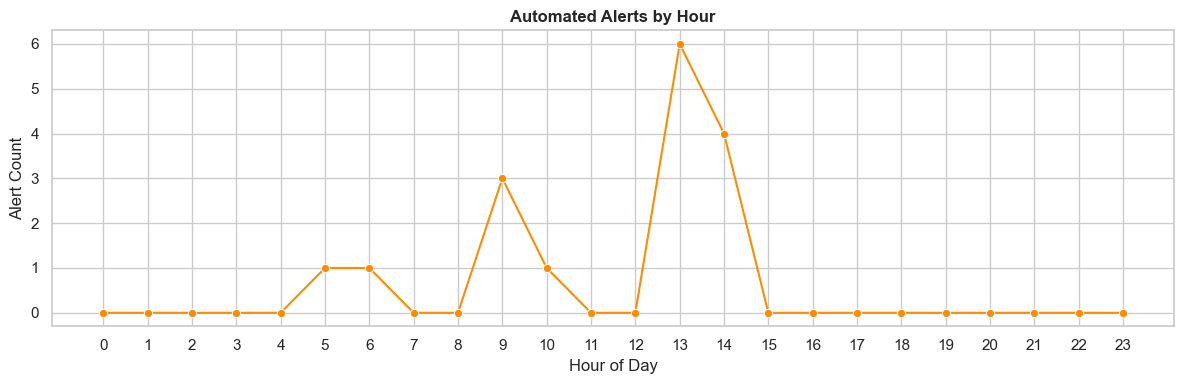

In [9]:
hourly_alerts = df.assign(hour=df["timestamp"].dt.hour).groupby("hour")["has_alert"].sum().reset_index()

plt.figure(figsize=(12, 4))
sns.lineplot(data=hourly_alerts, x="hour", y="has_alert", marker="o", color="darkorange")
plt.title("Automated Alerts by Hour", weight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Alert Count")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hourly_alerts.png", dpi=150, bbox_inches="tight")
plt.show()

## Linux Automation Extension

In a real Ubuntu machine, this notebook idea could be converted into a Python script and scheduled with cron. Example cron entry:

```bash
*/10 * * * * /usr/bin/python3 /home/user/system_health_monitor.py
```

This means the monitor would run automatically every 10 minutes.

## Conclusion

This automation scenario shows how Ubuntu system monitoring can be automated using Python. The system collects or simulates resource data, applies rules, creates logs, and visualizes the results. The same approach can be adapted for real servers by replacing the simulated values with live system commands or a library such as `psutil`.

## Reflection

Through this assignment, I learned how automation can reduce manual system administration work in an Ubuntu environment. Instead of checking CPU, memory, disk, and network usage manually, a script can collect metrics, apply rules, generate alerts, and save logs automatically. I also learned that visualization makes automation more useful because graphs quickly show when and where problems happen. This scenario helped me understand how Python, Linux-style logs, threshold rules, and scheduled tasks such as cron can work together in a practical monitoring workflow. Even though the data here is simulated, the same structure can be connected to real Ubuntu commands or monitoring libraries for real-world use.